In [ ]:
from pctk import multicellds
import pandas as pd
import matplotlib.pyplot as plt
from cobra.io import read_sbml_model

In [97]:
model = read_sbml_model("../config/Recon2.2_FBC_trimmed_final.xml")
model.reactions.EX_glc_e.lower_bound = -0.0
model.optimize()
s = model.summary()
s

Metabolite,Reaction,Flux,C-Number,C-Flux
ala_L_e,EX_ala_L_e,0.0427,3,2.12%
arg_L_e,EX_arg_L_e,0.05,6,4.97%
asn_L_e,EX_asn_L_e,0.0236,4,1.56%
chol_e,EX_chol_e,0.005,5,0.41%
cys_L_e,EX_cys_L_e,0.05,3,2.48%
gln_L_e,EX_gln_L_e,0.4631,5,38.32%
glu_L_e,EX_glu_L_e,0.05,5,4.14%
gthrd_e,EX_gthrd_e,0.05,10,8.28%
h_e,EX_h_e,0.5838,0,0.00%
his_L_e,EX_his_L_e,0.01067,6,1.06%


In [101]:
mcds_reader = multicellds.MultiCellDS("../output/")
col2idx = {n:i for i,n in enumerate(mcds_reader.cell_columns)}

columns = [
    "total_volume", "cell_dry_weight", "growth_rate", "R_biomass_reaction", 
    "oxygen_conc", "oxygen_total", "oxygen_NER", "R_EX_o2_e", 
    "glucose_conc", "glucose_total", "glucose_NER", "R_EX_glc_e", 
    "lactate_conc", "lactate_total", "lactate_NER", "R_EX_lac_D_e", 
    "co2_conc", "co2_total", "co2_NER", "R_EX_co2_e"
    ]

data = []
for t, a in mcds_reader.cells_as_matrix_iterator():
    if t == 0:
        continue
    
    row = [t]
    for c in columns:
        i = col2idx[c]
        value = a[0, i]
        row.append(value)
    data.append(row)

df = pd.DataFrame(data=data, columns=["time"] + columns)
df = df.set_index("time")
df

,total_volume,cell_dry_weight,growth_rate,R_biomass_reaction,oxygen_conc,oxygen_total,oxygen_NER,R_EX_o2_e,glucose_conc,glucose_total,glucose_NER,R_EX_glc_e,lactate_conc,lactate_total,lactate_NER,R_EX_lac_D_e,co2_conc,co2_total,co2_NER,R_EX_co2_e
time,,,,,,,,,,,,,,,,,,,,
1,2494.351029,785.720574,0.016889,-0.0,29.600587,9.990198e-11,-130659.588335,-9.977561,4.909739,1.657037e-11,-28976.974856,-2.212769,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.0


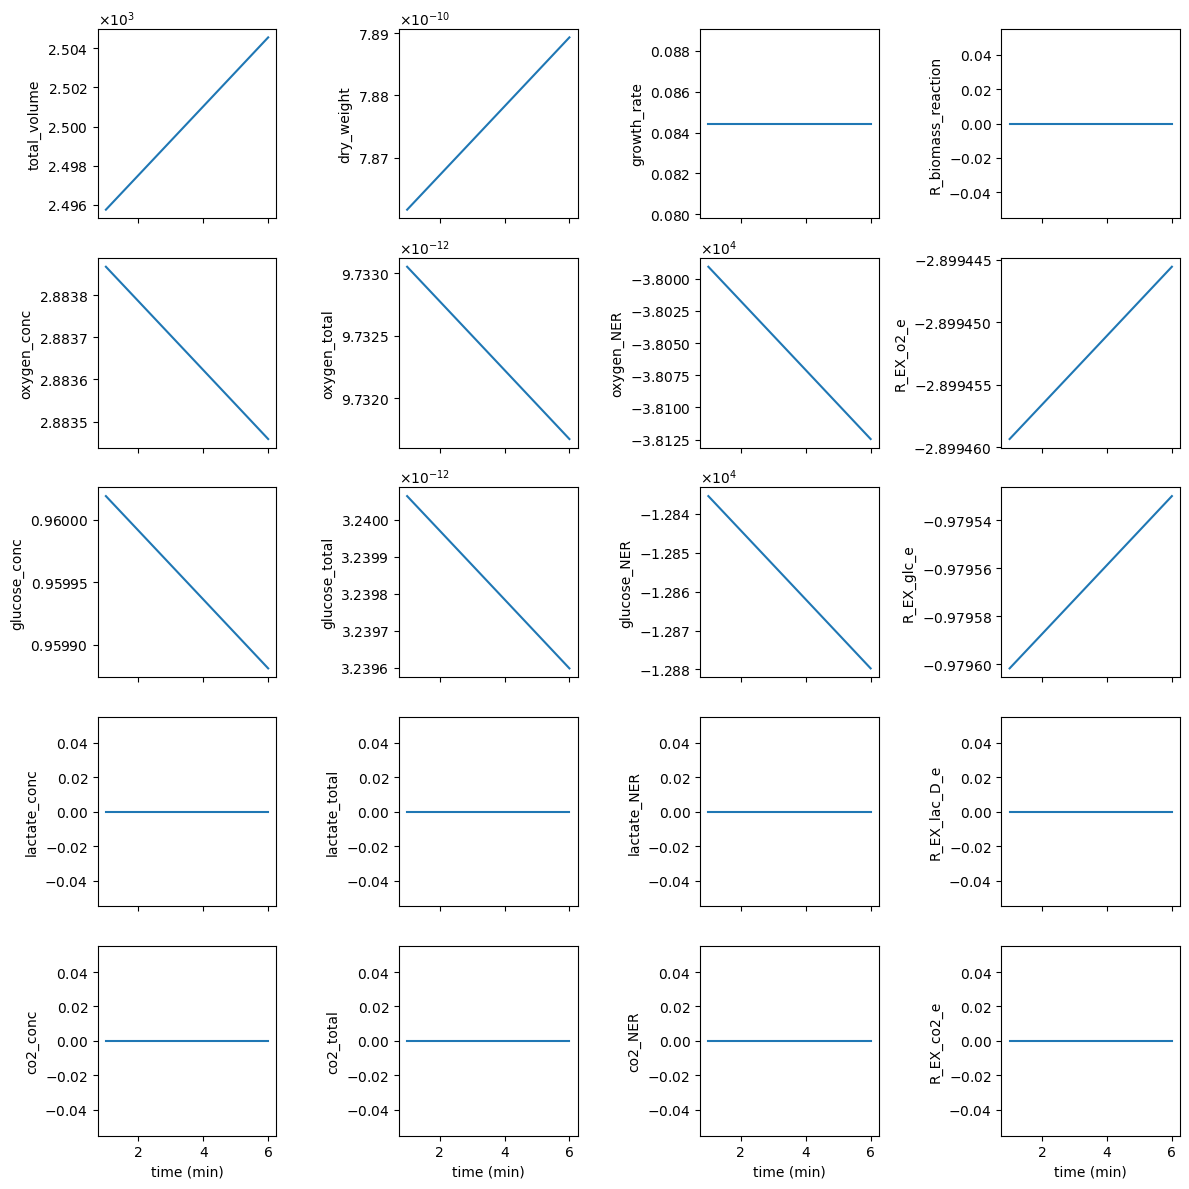

In [91]:
from matplotlib.ticker import ScalarFormatter
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(12, 12), sharex=True)

plots = [    
    ["total_volume", "dry_weight", "growth_rate", "R_biomass_reaction"],
    ["oxygen_conc", "oxygen_total", "oxygen_NER", "R_EX_o2_e"], 
    ["glucose_conc", "glucose_total", "glucose_NER", "R_EX_glc_e"], 
    ["lactate_conc", "lactate_total", "lactate_NER", "R_EX_lac_D_e"], 
    ["co2_conc", "co2_total", "co2_NER", "R_EX_co2_e"]
]

for row_idx, row in enumerate(plots):
    for col_idx, col in enumerate(row):

        ax = axes[row_idx, col_idx]
        ax.plot(df.index, df[col])
        ax.set_ylabel(col)

        # properly formatted scientific notation (no subtractions)
        fmt = ScalarFormatter(useMathText=True)
        fmt.set_scientific(True)
        fmt.set_powerlimits((-3, 3))
        fmt.set_useOffset(False)   # <<< absolutely critical
        ax.yaxis.set_major_formatter(fmt)

        if row_idx == len(plots) - 1:
            ax.set_xlabel("time (min)")

fig.tight_layout()